In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dataset từ thư mục data
data = pd.read_csv('gia_nha.csv', index_col='ID_nha')
data.head()

,Dien_tich,So_phong,Gia_ty
ID_nha,,,
1,50,2,2.5
2,80,3,4.8
3,45,1,1.8
4,120,4,7.5
5,60,2,2.9


In [3]:
# Trích xuất Features và Target
features = ['Dien_tich', 'So_phong']
X = data[features]
y = data['Gia_ty']

# Chia tập Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25, random_state=42)

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = [1, 3, 5, 7]
results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = np.mean((y_train - y_train_pred) ** 2)
    test_mse = np.mean((y_test - y_test_pred) ** 2)

    results.append([degree, train_mse, test_mse])

results_df = pd.DataFrame(results, columns=['Degree', 'Train MSE', 'Test MSE'])
results_df

,Degree,Train MSE,Test MSE
0,1,2.027102e-02,0.122413
1,3,2.636990e-24,0.355308
2,5,7.218346e-02,1.247116
3,7,1.039256e-01,6.543212


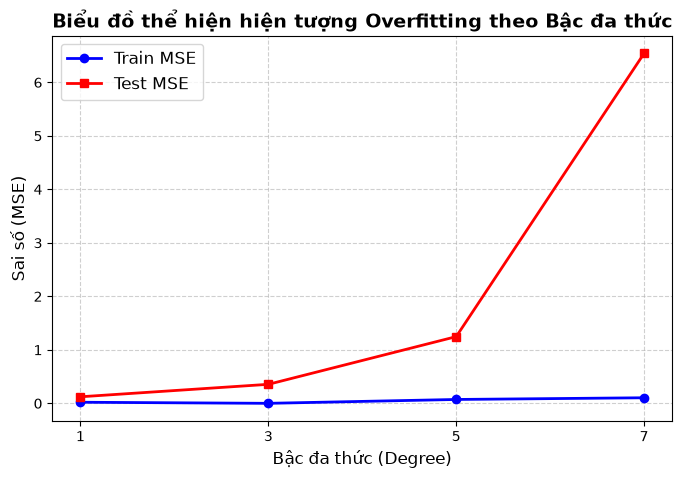

In [5]:
# Lọc lại kết quả từ vòng lặp trước để vẽ biểu đồ
# results_df chứa các cột: ['Degree', 'Train MSE', 'Test MSE']

plt.figure(figsize=(8, 5))

# Vẽ đường Train MSE màu xanh dương
plt.plot(results_df['Degree'], results_df['Train MSE'], marker='o', label='Train MSE', color='blue', linewidth=2)

# Vẽ đường Test MSE màu đỏ
plt.plot(results_df['Degree'], results_df['Test MSE'], marker='s', label='Test MSE', color='red', linewidth=2)

# Trang trí biểu đồ
plt.xlabel('Bậc đa thức (Degree)', fontsize=12)
plt.ylabel('Sai số (MSE)', fontsize=12)
plt.title('Biểu đồ thể hiện hiện tượng Overfitting theo Bậc đa thức', fontsize=14, fontweight='bold')
plt.xticks(results_df['Degree'])
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.show()